In [2]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.510399999976158 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [3]:
!mamba install scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.1128000000715255 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3

In [4]:
with open('GPL571_noParents.an.txt', 'r') as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print("\nLines 10-15 (where the error is):")
for i in range(10, min(15, len(lines))):
    print(f"\nLine {i+1}:")
    print(repr(lines[i][:300]))

Total lines: 22290

Lines 10-15 (where the error is):

Line 11:
'# GPL571  Affymetrix GeneChip Human Genome U133A 2.0 Array\n'

Line 12:
'# Homo sapiens\n'

Line 13:
'ElementName\tGeneSymbols\tGeneNames\tGOTerms\tGemmaIDs\tNCBIids\tEnsemblIds\n'

Line 14:
'202619_s_at\tPLOD2\tprocollagen-lysine,2-oxoglutarate 5-dioxygenase 2\tGO:0005506|GO:0001666|GO:0030867|GO:0031418|GO:0005789|GO:0070062|GO:0033823|GO:0005783|GO:0008475|GO:0006493|GO:0046947|GO:0017185|GO:0036211\t127276\t5352\tENSG00000152952\n'

Line 15:
'219952_s_at\tMCOLN1\tmucolipin TRP cation channel 1\tGO:0006812|GO:0051209|GO:0005764|GO:0005765|GO:0005886|GO:0097682|GO:0042995|GO:0005261|GO:0005262|GO:0002250|GO:1901660|GO:0019722|GO:0070588|GO:0099604|GO:0051289|GO:0072345|GO:0033572|GO:0071277|GO:0005515|GO:0031902|GO:0090382|GO:0005654|GO:00973'


In [5]:
import pandas as pd

print("="*60)
print("LOADING AND MAPPING DATA")
print("="*60)

# Load expression matrix
print("\n1. Loading expression matrix...")
expression = pd.read_csv('GSE1561_series_matrix.txt',
                          sep='\t',
                          comment='!',
                          index_col=0)

print(f"   ✓ {expression.shape[0]} probe sets × {expression.shape[1]} samples")
print(f"   Samples: {list(expression.columns)}")

# Load annotation file - skip comment lines (lines starting with #)
print("\n2. Loading annotation file...")
annotation = pd.read_csv('GPL571_noParents.an.txt',
                          sep='\t',
                          comment='#',  # Skip lines starting with #
                          low_memory=False)

print(f"   ✓ {annotation.shape[0]} probes in annotation")

# Check the column names
print(f"   Columns: {annotation.columns.tolist()}")

LOADING AND MAPPING DATA

1. Loading expression matrix...
   ✓ 22215 probe sets × 49 samples
   Samples: ['GSM26804', 'GSM26867', 'GSM26868', 'GSM26869', 'GSM26870', 'GSM26871', 'GSM26872', 'GSM26873', 'GSM26874', 'GSM26875', 'GSM26876', 'GSM26877', 'GSM26878', 'GSM26879', 'GSM26880', 'GSM26881', 'GSM26882', 'GSM26883', 'GSM26884', 'GSM26885', 'GSM26886', 'GSM26887', 'GSM26888', 'GSM26889', 'GSM26890', 'GSM26891', 'GSM26892', 'GSM26893', 'GSM26894', 'GSM26895', 'GSM26896', 'GSM26897', 'GSM26898', 'GSM26899', 'GSM26900', 'GSM26901', 'GSM26902', 'GSM26903', 'GSM26904', 'GSM26905', 'GSM26906', 'GSM26907', 'GSM26908', 'GSM26909', 'GSM26910', 'GSM26911', 'GSM26912', 'GSM26913', 'GSM26914']

2. Loading annotation file...
   ✓ 22277 probes in annotation
   Columns: ['ElementName', 'GeneSymbols', 'GeneNames', 'GOTerms', 'GemmaIDs', 'NCBIids', 'EnsemblIds']


In [6]:
import pandas as pd

print("="*50)
print("STEP 1.1: LOAD EXPRESSION FILE")
print("="*50)

# Load the expression matrix
# Skip lines starting with "!" (these are metadata)
expression = pd.read_csv('GSE1561_series_matrix.txt',
                          sep='\t',
                          comment='!',  # Skip metadata lines
                          index_col=0)  # First column is row names (probe IDs)

print(f"✓ Loaded successfully!")
print(f"  Shape: {expression.shape}")
print(f"  Genes (rows): {expression.shape[0]}")
print(f"  Samples (columns): {expression.shape[1]}")

print(f"\nSample names:")
print(list(expression.columns))

print(f"\nFirst 5 rows, first 5 columns:")
print(expression.iloc[:5, :5])

STEP 1.1: LOAD EXPRESSION FILE
✓ Loaded successfully!
  Shape: (22215, 49)
  Genes (rows): 22215
  Samples (columns): 49

Sample names:
['GSM26804', 'GSM26867', 'GSM26868', 'GSM26869', 'GSM26870', 'GSM26871', 'GSM26872', 'GSM26873', 'GSM26874', 'GSM26875', 'GSM26876', 'GSM26877', 'GSM26878', 'GSM26879', 'GSM26880', 'GSM26881', 'GSM26882', 'GSM26883', 'GSM26884', 'GSM26885', 'GSM26886', 'GSM26887', 'GSM26888', 'GSM26889', 'GSM26890', 'GSM26891', 'GSM26892', 'GSM26893', 'GSM26894', 'GSM26895', 'GSM26896', 'GSM26897', 'GSM26898', 'GSM26899', 'GSM26900', 'GSM26901', 'GSM26902', 'GSM26903', 'GSM26904', 'GSM26905', 'GSM26906', 'GSM26907', 'GSM26908', 'GSM26909', 'GSM26910', 'GSM26911', 'GSM26912', 'GSM26913', 'GSM26914']

First 5 rows, first 5 columns:
            GSM26804   GSM26867   GSM26868   GSM26869   GSM26870
ID_REF                                                          
1007_s_at  11.521196  10.367041  11.393114  11.102855  10.677565
1053_at     7.765484   8.143485   7.606404   7.3

In [ ]:
## Step 2.1: Load the Annotation File

In [7]:
import pandas as pd

print("="*50)
print("STEP 2.1: LOAD ANNOTATION FILE")
print("="*50)

# Load the annotation file
# Skip lines starting with "#" (comment lines)
annotation = pd.read_csv('GPL571_noParents.an.txt',
                          sep='\t',
                          comment='#',  # Skip comment lines
                          low_memory=False)

print(f"✓ Loaded successfully!")
print(f"  Probes in annotation: {len(annotation)}")

print(f"\nColumn names:")
print(annotation.columns.tolist())

print(f"\nFirst 5 rows:")
print(annotation[['ElementName', 'GeneSymbols']].head())

STEP 2.1: LOAD ANNOTATION FILE
✓ Loaded successfully!
  Probes in annotation: 22277

Column names:
['ElementName', 'GeneSymbols', 'GeneNames', 'GOTerms', 'GemmaIDs', 'NCBIids', 'EnsemblIds']

First 5 rows:
   ElementName GeneSymbols
0  202619_s_at       PLOD2
1  219952_s_at      MCOLN1
2    205192_at     MAP3K14
3  204991_s_at         NF2
4    207373_at      HOXD10


In [7]:
## Create the Mapping 

In [8]:
print("\n" + "="*50)
print("STEP 2.2: CREATE PROBE TO GENE MAPPING")
print("="*50)

# Create a dictionary mapping probe ID → gene symbol
probe_to_gene = dict(zip(annotation['ElementName'], annotation['GeneSymbols']))

print(f"✓ Created mapping for {len(probe_to_gene)} probes")

# Show some examples
print("\nExample mappings:")
sample_probes = list(probe_to_gene.keys())[:5]
for probe in sample_probes:
    gene = probe_to_gene[probe]
    print(f"  {probe} → {gene}")


STEP 2.2: CREATE PROBE TO GENE MAPPING
✓ Created mapping for 22277 probes

Example mappings:
  202619_s_at → PLOD2
  219952_s_at → MCOLN1
  205192_at → MAP3K14
  204991_s_at → NF2
  207373_at → HOXD10


In [9]:
##Apply the Mapping to Expression Data

In [9]:
print("\n" + "="*50)
print("STEP 2.3: APPLY MAPPING TO EXPRESSION DATA")
print("="*50)

# Apply mapping to expression matrix
# Replace probe IDs (row names) with gene symbols
expression.index = expression.index.map(probe_to_gene)

print(f"✓ Applied mapping")

# Count how many probes had gene symbols
mapped_count = sum(expression.index.notna())
unmapped_count = sum(expression.index.isna())

print(f"\n  Mapped to gene symbols: {mapped_count}")
print(f"  Could not map (NaN): {unmapped_count}")


STEP 2.3: APPLY MAPPING TO EXPRESSION DATA
✓ Applied mapping

  Mapped to gene symbols: 19050
  Could not map (NaN): 3165


In [10]:
print("="*50)
print("STEP 2.4: CLEAN DATA - REMOVE UNMAPPED PROBES")
print("="*50)

# Keep only rows with gene symbols (remove NaN)
expression_clean = expression[expression.index.notna()]

print(f"✓ Removed unmapped probes")
print(f"\nData summary:")
print(f"  Genes (rows): {expression_clean.shape[0]}")
print(f"  Samples (columns): {expression_clean.shape[1]}")

print(f"\nFirst 10 gene names:")
print(list(expression_clean.index[:10]))

STEP 2.4: CLEAN DATA - REMOVE UNMAPPED PROBES
✓ Removed unmapped probes

Data summary:
  Genes (rows): 19050
  Samples (columns): 49

First 10 gene names:
['DDR1', 'RFC2', 'HSPA6|HSPA7', 'PAX8', 'GUCA1ANB-GUCA1A|GUCA1A', 'UBA7', 'THRA', 'PTPN21', 'CCL5', 'CYP2E1']


In [11]:
print("="*50)
print("STEP 3.1: CHECK DATA INTEGRITY")
print("="*50)

import numpy as np

print("\n1. Missing values check:")
missing = expression_clean.isna().sum().sum()
print(f"   Total missing values: {missing}")

print("\n2. Data type check:")
print(f"   Data types per column:")
print(expression_clean.dtypes.value_counts())

print("\n3. Value range check (log2 data):")
print(f"   Min value: {expression_clean.min().min():.2f}")
print(f"   Max value: {expression_clean.max().max():.2f}")
print(f"   Mean value: {expression_clean.mean().mean():.2f}")

print("\n4. Sample names:")
print(f"   {list(expression_clean.columns)}")

STEP 3.1: CHECK DATA INTEGRITY

1. Missing values check:
   Total missing values: 0

2. Data type check:
   Data types per column:
float64    49
Name: count, dtype: int64

3. Value range check (log2 data):
   Min value: 4.00
   Max value: 14.27
   Mean value: 7.68

4. Sample names:
   ['GSM26804', 'GSM26867', 'GSM26868', 'GSM26869', 'GSM26870', 'GSM26871', 'GSM26872', 'GSM26873', 'GSM26874', 'GSM26875', 'GSM26876', 'GSM26877', 'GSM26878', 'GSM26879', 'GSM26880', 'GSM26881', 'GSM26882', 'GSM26883', 'GSM26884', 'GSM26885', 'GSM26886', 'GSM26887', 'GSM26888', 'GSM26889', 'GSM26890', 'GSM26891', 'GSM26892', 'GSM26893', 'GSM26894', 'GSM26895', 'GSM26896', 'GSM26897', 'GSM26898', 'GSM26899', 'GSM26900', 'GSM26901', 'GSM26902', 'GSM26903', 'GSM26904', 'GSM26905', 'GSM26906', 'GSM26907', 'GSM26908', 'GSM26909', 'GSM26910', 'GSM26911', 'GSM26912', 'GSM26913', 'GSM26914']


In [14]:
#  CHECK SAMPLE DISTRIBUTION

In [12]:
print("="*50)
print("STEP 3.2: CHECK SAMPLE DISTRIBUTION")
print("="*50)

import numpy as np

# Calculate mean expression per sample
sample_means = expression_clean.mean(axis=0)

print("\nMean expression per sample:")
print(sample_means.round(2))

print(f"\nOverall mean: {sample_means.mean():.2f}")
print(f"Std deviation: {sample_means.std():.2f}")

# Check for outliers
print("\nChecking for outliers:")
mean_all = sample_means.mean()
std_all = sample_means.std()

for sample in sample_means.index:
    deviation = abs(sample_means[sample] - mean_all)
    if deviation > 2 * std_all:
        print(f"   ⚠️  {sample}: deviation = {deviation:.2f}")
    else:
        pass  # Don't print everything, too long

print("\n✓ Outlier check complete")

STEP 3.2: CHECK SAMPLE DISTRIBUTION

Mean expression per sample:
GSM26804    7.68
GSM26867    7.69
GSM26868    7.67
GSM26869    7.69
GSM26870    7.69
GSM26871    7.69
GSM26872    7.68
GSM26873    7.69
GSM26874    7.69
GSM26875    7.67
GSM26876    7.69
GSM26877    7.68
GSM26878    7.67
GSM26879    7.69
GSM26880    7.69
GSM26881    7.70
GSM26882    7.67
GSM26883    7.66
GSM26884    7.67
GSM26885    7.68
GSM26886    7.68
GSM26887    7.68
GSM26888    7.68
GSM26889    7.68
GSM26890    7.69
GSM26891    7.70
GSM26892    7.70
GSM26893    7.66
GSM26894    7.69
GSM26895    7.67
GSM26896    7.67
GSM26897    7.69
GSM26898    7.68
GSM26899    7.66
GSM26900    7.68
GSM26901    7.70
GSM26902    7.67
GSM26903    7.68
GSM26904    7.69
GSM26905    7.67
GSM26906    7.68
GSM26907    7.68
GSM26908    7.72
GSM26909    7.67
GSM26910    7.68
GSM26911    7.66
GSM26912    7.67
GSM26913    7.70
GSM26914    7.67
dtype: float64

Overall mean: 7.68
Std deviation: 0.01

Checking for outliers:
   ⚠️  GSM26908: deviat

In [16]:
# PCA VISUALIZATION

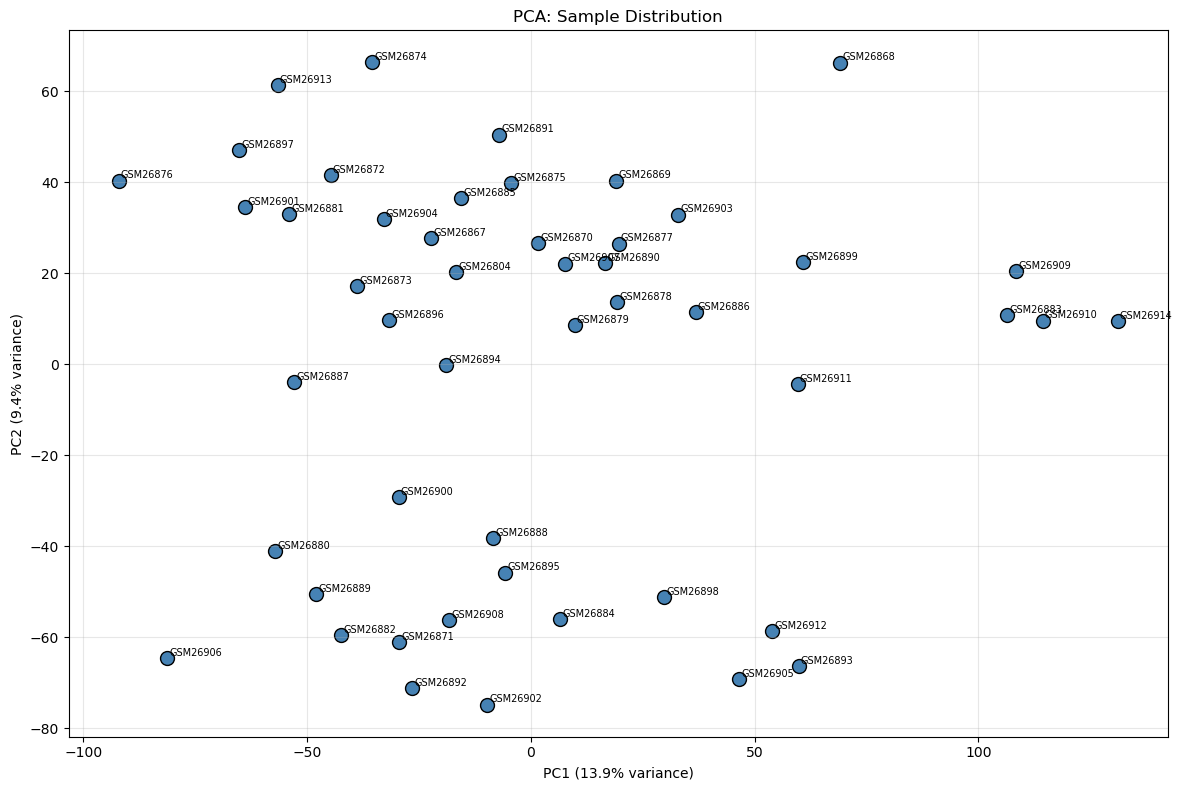

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Prepare data
X = expression_clean.T.values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=100, c='steelblue', edgecolors='black')
for i, sample in enumerate(expression_clean.columns):
    plt.annotate(sample, (X_pca[i, 0] + 0.5, X_pca[i, 1] + 0.5), fontsize=7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: Sample Distribution')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150)
plt.show()

In [20]:
print("="*60)
print("STEP 4.4: SAMPLE CLASSIFICATION")
print("="*60)

print("\nChecking available markers in data:")
available = ['ESR1', 'PGR', 'ERBB2', 'MKI67', 'EGFR', 'KRT5', 'TP53']
for gene in available:
    if gene in expression_clean.index:
        print(f"  ✓ {gene}")
    else:
        print(f"  ✗ {gene} - NOT FOUND")

STEP 4.4: SAMPLE CLASSIFICATION

Checking available markers in data:
  ✓ ESR1
  ✓ PGR
  ✓ ERBB2
  ✓ MKI67
  ✓ EGFR
  ✓ KRT5
  ✓ TP53


In [21]:
print("Checking for duplicate gene names:")
duplicates = expression_clean.index[expression_clean.index.duplicated()].unique()
print(f"Duplicate genes: {len(duplicates)}")
if len(duplicates) > 0:
    print(duplicates[:10])

Checking for duplicate gene names:
Duplicate genes: 4070
Index(['GDI2', 'EIF3A', 'PRKAR1A', 'RAD21', 'WDR1', 'AP2B1', 'MLEC', 'CALM3',
       'MATR3', 'WARS1'],
      dtype='str', name='ID_REF')


In [22]:
print("\nFixing duplicates by taking mean...")

# If there are duplicates, take the mean of each gene
expression_clean = expression_clean.groupby(expression_clean.index).mean()

print(f"New shape: {expression_clean.shape}")


Fixing duplicates by taking mean...
New shape: (12905, 49)


In [23]:
print("\n" + "="*60)
print("SAMPLE CLASSIFICATION")
print("="*60)

results = []

for sample in expression_clean.columns:
    esr1 = expression_clean.loc['ESR1', sample]
    erbb2 = expression_clean.loc['ERBB2', sample]
    ki67 = expression_clean.loc['MKI67', sample]

    # Classification (simple if/else)
    if esr1 > 8 and erbb2 < 10:
        subtype = "Luminal A"
    elif esr1 > 8 and erbb2 > 10:
        subtype = "Luminal B"
    elif erbb2 > 10:
        subtype = "HER2-enriched"
    else:
        subtype = "Triple-Negative"

    results.append({
        'Sample': sample,
        'ESR1': round(esr1, 2),
        'ERBB2': round(erbb2, 2),
        'MKI67': round(ki67, 2),
        'Subtype': subtype
    })

summary_df = pd.DataFrame(results)

print("\nClassification Results:")
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print("SUBTYPE DISTRIBUTION")
print("="*60)
print(summary_df['Subtype'].value_counts())


SAMPLE CLASSIFICATION

Classification Results:
  Sample  ESR1  ERBB2  MKI67         Subtype
GSM26804  7.71   7.05   7.58 Triple-Negative
GSM26867  7.51   8.60   8.93 Triple-Negative
GSM26868  8.17   7.23   7.37       Luminal A
GSM26869  7.87   7.21   7.06 Triple-Negative
GSM26870  7.51   9.04   7.49 Triple-Negative
GSM26871  6.92   6.72   8.09 Triple-Negative
GSM26872  7.76   6.94   6.99 Triple-Negative
GSM26873  7.36   8.27   7.43 Triple-Negative
GSM26874  7.95   7.17   7.07 Triple-Negative
GSM26875  8.02   7.19   8.10       Luminal A
GSM26876  7.90   6.80   7.29 Triple-Negative
GSM26877  7.83   7.02   7.45 Triple-Negative
GSM26878  7.16   8.24   7.75 Triple-Negative
GSM26879  7.75   7.01   7.92 Triple-Negative
GSM26880  6.93   6.68   8.15 Triple-Negative
GSM26881  7.84   6.97   7.60 Triple-Negative
GSM26882  7.03   6.60   8.06 Triple-Negative
GSM26883  6.96   8.54   7.66 Triple-Negative
GSM26884  6.86   6.93   8.42 Triple-Negative
GSM26885  7.76   7.07   7.01 Triple-Negative
GSM2688

In [24]:
print("="*60)
print("CHECKING MARKER EXPRESSION VALUES")
print("="*60)

# Check ESR1 and ERBB2 values across all samples
esr1_values = expression_clean.loc['ESR1']
erbb2_values = expression_clean.loc['ERBB2']

print("\nESR1 (Estrogen Receptor) values:")
print(f"  Min: {esr1_values.min():.2f}")
print(f"  Max: {esr1_values.max():.2f}")
print(f"  Mean: {esr1_values.mean():.2f}")
print(f"  Samples > 8 (ER+): {(esr1_values > 8).sum()}")
print(f"  Samples <= 8 (ER-): {(esr1_values <= 8).sum()}")

print("\nERBB2 (HER2) values:")
print(f"  Min: {erbb2_values.min():.2f}")
print(f"  Max: {erbb2_values.max():.2f}")
print(f"  Mean: {erbb2_values.mean():.2f}")
print(f"  Samples > 10 (HER2+): {(erbb2_values > 10).sum()}")
print(f"  Samples <= 10 (HER2-): {(erbb2_values <= 10).sum()}")

CHECKING MARKER EXPRESSION VALUES

ESR1 (Estrogen Receptor) values:
  Min: 6.86
  Max: 8.25
  Mean: 7.47
  Samples > 8 (ER+): 6
  Samples <= 8 (ER-): 43

ERBB2 (HER2) values:
  Min: 6.39
  Max: 9.04
  Mean: 7.33
  Samples > 10 (HER2+): 0
  Samples <= 10 (HER2-): 49


In [25]:
print("="*60)
print("ADDITIONAL MARKER ANALYSIS")
print("="*60)

# Check other markers
print("\nProliferation marker (MKI67/Ki-67):")
mki67 = expression_clean.loc['MKI67']
print(f"  Range: {mki67.min():.2f} - {mki67.max():.2f}")
print(f"  Mean: {mki67.mean():.2f}")

print("\nBasal marker (KRT5):")
krt5 = expression_clean.loc['KRT5']
print(f"  Range: {krt5.min():.2f} - {krt5.max():.2f}")
print(f"  Mean: {krt5.mean():.2f}")

print("\nTP53 (Tumor suppressor):")
tp53 = expression_clean.loc['TP53']
print(f"  Range: {tp53.min():.2f} - {tp53.max():.2f}")
print(f"  Mean: {tp53.mean():.2f}")

ADDITIONAL MARKER ANALYSIS

Proliferation marker (MKI67/Ki-67):
  Range: 6.99 - 9.57
  Mean: 7.81

Basal marker (KRT5):
  Range: 7.55 - 12.80
  Mean: 9.04

TP53 (Tumor suppressor):
  Range: 5.63 - 7.19
  Mean: 6.34


In [30]:
print("="*60)
print("STEP 5.1: DEFINE SAMPLE GROUPS")
print("="*60)

# Define groups based on ESR1 expression
luminal_a_samples = [s for s in expression_clean.columns if expression_clean.loc['ESR1', s] > 8]
tnbc_samples = [s for s in expression_clean.columns if expression_clean.loc['ESR1', s] <= 8]

print(f"\nLuminal A (ER+): {len(luminal_a_samples)} samples")
print(f"  {luminal_a_samples}")

print(f"\nTriple-Negative (ER-): {len(tnbc_samples)} samples")
print(f"  (showing first 10: {tnbc_samples[:10]}...)")

STEP 5.1: DEFINE SAMPLE GROUPS

Luminal A (ER+): 6 samples
  ['GSM26868', 'GSM26875', 'GSM26891', 'GSM26901', 'GSM26911', 'GSM26914']

Triple-Negative (ER-): 43 samples
  (showing first 10: ['GSM26804', 'GSM26867', 'GSM26869', 'GSM26870', 'GSM26871', 'GSM26872', 'GSM26873', 'GSM26874', 'GSM26876', 'GSM26877']...)


In [31]:

## Step 5.2: Differential Expression (Gene by Gene)
print("\n" + "="*60)
print("STEP 5.2: DIFFERENTIAL EXPRESSION ANALYSIS")
print("="*60)

from scipy import stats
import numpy as np

# Get expression data for each group
luminal_expr = expression_clean[luminal_a_samples]
tnbc_expr = expression_clean[tnbc_samples]

print(f"\nComparing: Luminal A (n={len(luminal_a_samples)}) vs Triple-Negative (n={len(tnbc_samples)})")

results = []

for gene in expression_clean.index:
    luminal_values = luminal_expr.loc[gene].values
    tnbc_values = tnbc_expr.loc[gene].values

    # T-test
    t_stat, p_value = stats.ttest_ind(luminal_values, tnbc_values)

    # Mean values
    mean_luminal = np.mean(luminal_values)
    mean_tnbc = np.mean(tnbc_values)

    # Fold change (in log2 space, just subtract)
    log2_fc = mean_luminal - mean_tnbc

    # Store results
    results.append({
        'Gene': gene,
        'Mean_Luminal_A': mean_luminal,
        'Mean_TNBC': mean_tnbc,
        'Log2_FoldChange': log2_fc,
        'T_statistic': t_stat,
        'P_value': p_value
    })

# Create results DataFrame
de_results = pd.DataFrame(results)
print(f"\n✓ Analyzed {len(de_results)} genes")

# Show top results
de_results_sorted = de_results.sort_values('P_value')
print("\nTop 10 most significant genes:")
print(de_results_sorted[['Gene', 'Log2_FoldChange', 'P_value']].head(10).to_string(index=False))


STEP 5.2: DIFFERENTIAL EXPRESSION ANALYSIS

Comparing: Luminal A (n=6) vs Triple-Negative (n=43)

✓ Analyzed 12905 genes

Top 10 most significant genes:
   Gene  Log2_FoldChange      P_value
   PHF7         0.247243 4.453883e-08
SLC27A2         2.149242 2.048737e-07
  NOVA1         0.918168 4.958165e-07
    QKI        -0.677107 5.315635e-06
    HPN         0.815339 7.017552e-06
    VIM        -0.836986 7.366422e-06
  ANXA1        -1.220686 1.071751e-05
 MARCKS        -0.770421 1.071843e-05
   ESR1         0.784675 1.291620e-05
  IL6ST         1.635577 1.347668e-05


In [28]:
print("\n" + "="*60)
print("STEP 5.3: FILTER SIGNIFICANT GENES")
print("="*60)

# Add significance column
de_results['Significant'] = de_results['P_value'] < 0.05

# Add direction
de_results['Direction'] = de_results['Log2_FoldChange'].apply(
    lambda x: 'Upregulated in Luminal A' if x > 0 else 'Downregulated in Luminal A'
)

# Filter significant
significant_genes = de_results[de_results['Significant'] == True]

print(f"\nSignificant genes (p < 0.05): {len(significant_genes)}")

# Count up/down
up_in_luminal = len(significant_genes[significant_genes['Log2_FoldChange'] > 0])
down_in_luminal = len(significant_genes[significant_genes['Log2_FoldChange'] < 0])

print(f"  Upregulated in Luminal A: {up_in_luminal}")
print(f"  Downregulated in Luminal A (upregulated in TNBC): {down_in_luminal}")


STEP 5.3: FILTER SIGNIFICANT GENES

Significant genes (p < 0.05): 1790
  Upregulated in Luminal A: 1118
  Downregulated in Luminal A (upregulated in TNBC): 672


STEP 5.4: VOLCANO PLOT


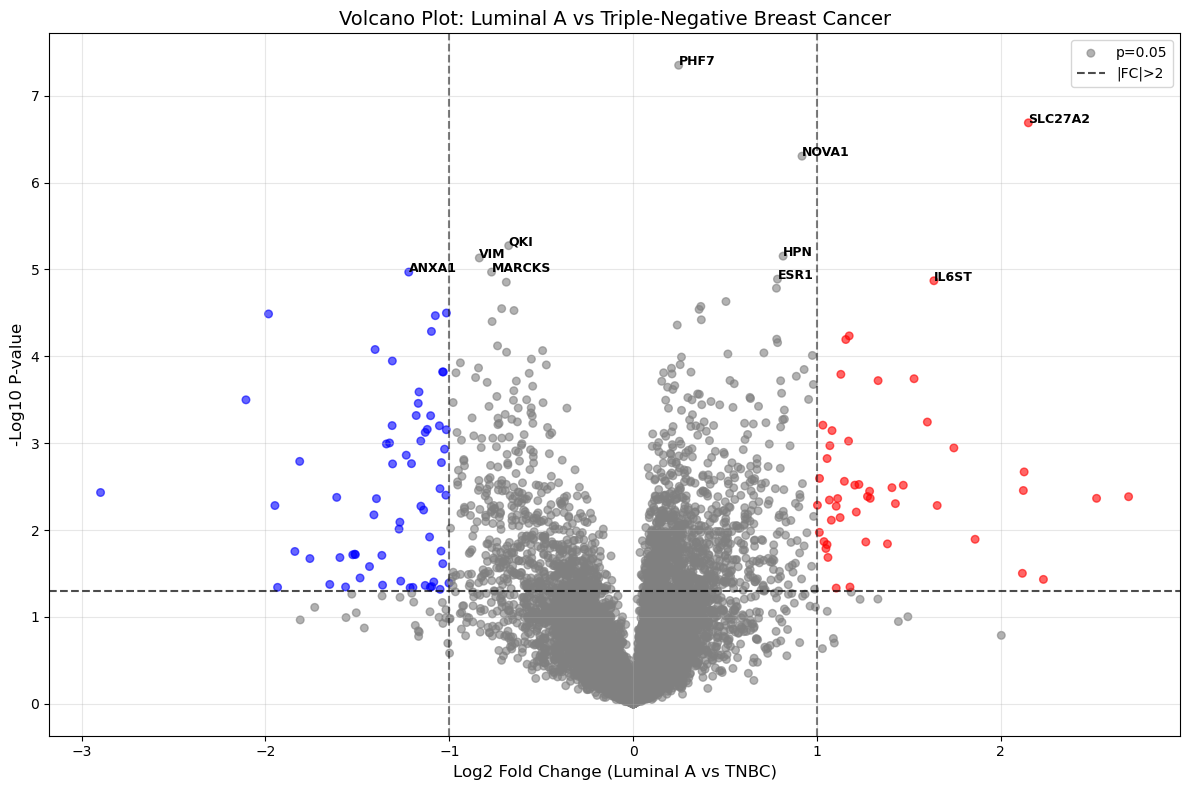

In [32]:
print("="*60)
print("STEP 5.4: VOLCANO PLOT")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# First, add the NegLogP column to de_results
de_results['NegLogP'] = -np.log10(de_results['P_value'] + 1e-300)

# Create volcano plot
plt.figure(figsize=(12, 8))

# Color coding
colors = []
for _, row in de_results.iterrows():
    if row['P_value'] < 0.05 and row['Log2_FoldChange'] > 1:
        colors.append('red')  # Upregulated in Luminal A
    elif row['P_value'] < 0.05 and row['Log2_FoldChange'] < -1:
        colors.append('blue')  # Downregulated in Luminal A (upregulated in TNBC)
    else:
        colors.append('gray')  # Not significant

plt.scatter(de_results['Log2_FoldChange'], de_results['NegLogP'],
            c=colors, alpha=0.6, s=30)

# Add threshold lines
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', alpha=0.7, label='p=0.05')
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=-1, color='black', linestyle='--', alpha=0.5)

# Label top genes (top 10 by p-value)
de_results_sorted = de_results.sort_values('P_value')
top_genes = de_results_sorted.head(10)

for _, row in top_genes.iterrows():
    plt.annotate(row['Gene'],
                 (row['Log2_FoldChange'], row['NegLogP']),
                 fontsize=9, fontweight='bold')

plt.xlabel('Log2 Fold Change (Luminal A vs TNBC)', fontsize=12)
plt.ylabel('-Log10 P-value', fontsize=12)
plt.title('Volcano Plot: Luminal A vs Triple-Negative Breast Cancer', fontsize=14)
plt.legend(['p=0.05', '|FC|>2'], loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=150, bbox_inches='tight')
plt.show()